# 01. Foreground segmentation

## Pipeline Overview

Every image passes through 5 main stages:

1. Prior and Prompt Generation (`grain_stages`)
   * Runs downscaled (around 4x) to reduce computational cost.
   * Extracts a rough foreground ("loose" prior) and shrinks it to a guaranteed interior of rice ("core").
   * Filters out specular highlights and glare to find safe regions to pick the positive point prompts.
   * Calculates point seeds and a bounding box prompt for SAM.

2. SAM Masking (`sam_mask`)
   * Passes the full resolution image, point seeds, and bounding box into SAM (ViT-B) to get 3 candidate masks.

3. Shadow Removal and Cleaning (`sam_mask`)
   * Applies an HLS saturation filter at full resolution to clean up cast shadows.
   * Keeps only the largest connected component to discard stray noise.

4. Vertical Alignment (`align_vertical`)
   * Rotates the grain along its long axis to align it vertically and centers it on a clean canvas.

---

## Configuration

Before running the code, set your paths and model checkpoint in `config.py`:

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import config as cfg
import cv2
import numpy as np
import torch
from pathlib import Path
from tqdm import tqdm
from segment_anything import sam_model_registry, SamPredictor
import matplotlib.pyplot as plt
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

sam = sam_model_registry["vit_b"](checkpoint=cfg.SAM_CHECKPOINT_PATH).to(device)
predictor = SamPredictor(sam)

Using device: cuda


c:\venv_codeskr\torch_cuda_env\Lib\site-packages\segment_anything\build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


## Functions


In [30]:
def largest_connected_component(mask):
    """Keep only the largest blob in a binary mask."""
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    if n <= 1:
        return mask
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    out = np.zeros_like(mask)
    out[labels == largest] = 255
    return out

# def pick_grain_component(closed, S, min_area=2000):
#     """Choose the most grain-like blob: compact (high fill) AND low-saturation (grey).
#     Robust on faded sheets where a background patch out-sizes the grain."""
#     n, labels, stats, _ = cv2.connectedComponentsWithStats(closed, 8)
#     if n <= 1:
#         return closed
#     best, bi = -1.0, 0
#     for i in range(1, n):
#         area = stats[i, cv2.CC_STAT_AREA]
#         if area < min_area:
#             continue
#         m = labels == i
#         bw, bh = stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
#         fill = area / (bw * bh)                        # solidity within bbox
#         sat  = 1.0 - min(np.median(S[m]) / cfg.HLS_S_MAX, 1.0)   # 1 = grey, 0 = blue
#         grain_score = fill * sat
#         if grain_score > best:
#             best, bi = grain_score, i
#     out = np.zeros_like(closed)
#     out[labels == bi] = 255
#     return out
def pick_grain_component(closed, S, min_area=2000):
    # print(">>> centrality active")
    """Choose the most grain-like blob. A grain is compact, low-saturation (grey),
    elongated, and near the frame centre — so a grey background corner patch,
    which fails elongation and centrality, no longer wins."""
    n, labels, stats, cent = cv2.connectedComponentsWithStats(closed, 8)
    if n <= 1:
        return closed
    H, W = closed.shape
    best, bi = -1.0, 0
    for i in range(1, n):
        area = stats[i, cv2.CC_STAT_AREA]
        if area < min_area:
            continue
        m = labels == i
        bw, bh = stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
        cx, cy = cent[i]

        fill   = area / (bw * bh)                                   # compact
        sat    = 1.0 - min(np.median(S[m]) / cfg.HLS_S_MAX, 1.0)    # grey, not blue
        elong  = max(bw, bh) / max(min(bw, bh), 1)                  # long, not blobby
        elong  = min(elong / 3.0, 1.0)                              # saturate at ~3:1
        centre = 1.0 - min(np.hypot((cx - W/2)/(W/2),
                                    (cy - H/2)/(H/2)), 1.0)         # near frame centre

        grain_score = fill * sat * elong * centre
        if grain_score > best:
            best, bi = grain_score, i
    out = np.zeros_like(closed)
    out[labels == bi] = 255
    return out

def get_seedpoints(image_bgr, scale=4, erode_frac=0.11, spec_k=2.5,
                   margin_frac=0.02, matte_bias=0.65, n_seeds=2):
    """
    Produce positive point prompts for SAM.
    Runs on a scale=4 downscale to stay cheap; seeds are returned in full-res coords.
    Returns a dict of stage masks (for the debug view) plus 'seeds'.

    scale       : downscale factor for the working image.
    erode_frac  : erosion radius as a fraction of grain diameter (confident core).
    spec_k      : specular threshold in std-devs above the grain's median L.
    margin_frac : highlight safety margin as a fraction of diameter.
    matte_bias  : 0 = pure depth, 1 = strongly favour dark pixels.
    n_seeds     : number of seeds along the grain's long axis.
    """
    h, w = image_bgr.shape[:2]
    small = cv2.resize(image_bgr, (w // scale, h // scale), interpolation=cv2.INTER_AREA)
    hls = cv2.cvtColor(small, cv2.COLOR_BGR2HLS)
    L, S = hls[:, :, 1], hls[:, :, 2]

    # loose foreground: rough grain location from the saturation threshold
    raw = cv2.inRange(hls, np.array([0, 0, cfg.HLS_S_MIN], np.uint8),
                           np.array([255, 255, cfg.HLS_S_MAX], np.uint8))
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    closed = cv2.morphologyEx(cv2.morphologyEx(raw, cv2.MORPH_OPEN, k, 2),
                              cv2.MORPH_CLOSE, k, 2)

    ko = max(7, int(min(h, w) / scale * 0.02)) | 1        # ~2% of frame short side, odd
    closed = cv2.morphologyEx(closed, cv2.MORPH_OPEN,
                              cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ko, ko)))
    # loose = largest_connected_component(closed)
    loose = pick_grain_component(closed, S, min_area=2000)

    d = dict(small=small, L=L, S=S, raw=raw, closed=closed, loose=loose,
             scale=scale, n_seeds=n_seeds)
    if loose.sum() == 0:
        d.update(core=loose, highlight=loose, allowed=loose,
                 score=loose.astype(np.float32), seeds=[(w // 2, h // 2)], rel_thr=0)
        return d

    # confident core: erode away the leaky rim to keep only sure-grain interior
    diam = 2 * np.sqrt(loose.sum() / 255 / np.pi)
    er = max(2, int(diam * erode_frac))
    core = largest_connected_component(
        cv2.erode(loose, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*er+1, 2*er+1)), 1))
    if core.sum() == 0:
        core = loose.copy()
    cb = core > 0

    # relative specular: bright vs this grain's own stats, excluded with a margin
    Lc, Sc = L[cb], S[cb]
    rel_thr = float(np.median(Lc) + spec_k * Lc.std())
    highlight = ((L >= rel_thr) & (S <= np.median(Sc)) & cb).astype(np.uint8) * 255
    r = max(1, int(diam * margin_frac))
    hl_d = cv2.dilate(highlight, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1)))
    allowed = cv2.bitwise_and(core, cv2.bitwise_not(hl_d))
    if allowed.sum() == 0:
        allowed = core.copy()

    # score = depth (distance transform) x matte weight (darkness)
    dt = cv2.distanceTransform(allowed, cv2.DIST_L2, 5)
    if dt.max() == 0:
        dt = cv2.distanceTransform(core, cv2.DIST_L2, 5)
    dt_n = dt / (dt.max() or 1)
    lo, hi = np.percentile(Lc, 5), np.percentile(Lc, 95)
    Ln = np.clip((L.astype(np.float32) - lo) / max(hi - lo, 1), 0, 1)
    score = dt_n * ((1 - matte_bias) + matte_bias * (1 - Ln))
    score[allowed == 0] = 0

    # one seed at the top-scoring point of each vertical band
    ys = np.where(cb.max(axis=1))[0]
    y0, y1 = ys.min(), ys.max()
    seeds = []
    for i in range(n_seeds):
        band = score.copy()
        band[:y0 + (y1 - y0) * i // n_seeds] = 0
        band[y0 + (y1 - y0) * (i + 1) // n_seeds:] = 0
        if band.max() > 0:
            sy, sx = np.unravel_index(np.argmax(band), band.shape)
            seeds.append((int(sx * scale), int(sy * scale)))
    if not seeds:
        seeds = [(w // 2, h // 2)]

    d.update(core=core, highlight=highlight, allowed=allowed, score=score,
             seeds=seeds, rel_thr=rel_thr)
    return d

def fill_holes(mask):
    """Fill internal holes in a binary mask (e.g. bran/chalk gaps inside the grain)."""
    h, w = mask.shape[:2]
    ff = mask.copy()
    m2 = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(ff, m2, (0, 0), 255)          # flood background from a corner
    holes = cv2.bitwise_not(ff)                 # everything the flood couldn't reach = holes
    return cv2.bitwise_or(mask, holes)


def check_segmentation(mask, min_area_frac=0.03, max_patch_frac=0.10):
    """
    Validate a final grain mask. Returns (ok: bool, reason: str).
      - 'too small'  : largest blob is below min_area_frac of the frame (under-segmentation).
      - 'has patches': a second component exists larger than max_patch_frac of the grain.
    """
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    if n <= 1:
        return False, "empty"
    areas = stats[1:, cv2.CC_STAT_AREA]
    order = np.argsort(areas)[::-1]
    main = areas[order[0]]

    if main / mask.size < min_area_frac:
        return False, f"too small ({main / mask.size:.4f})"
    if len(areas) > 1 and areas[order[1]] / main > max_patch_frac:
        return False, f"has patches ({len(areas)} blobs)"
    return True, "ok"


def sam_mask(image_bgr):
    """Segment one grain: SAM from seed points, then HLS shadow filter + largest component."""
    predictor.set_image(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    S = get_seedpoints(image_bgr)

    pts = np.array(S["seeds"])
    labels = np.ones(len(pts), int)
    masks, scores, _ = predictor.predict(point_coords=pts, point_labels=labels,
                                         multimask_output=True)
    mask = masks[np.argmax(scores)].astype(np.uint8) * 255

    hls = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HLS)
    mask = cv2.bitwise_and(mask, cv2.inRange(hls, np.array([0, 0, cfg.HLS_S_MIN], np.uint8),
                                                  np.array([255, 255, cfg.HLS_S_MAX], np.uint8)))
    mask = largest_connected_component(mask)
    mask = fill_holes(mask)
    return largest_connected_component(mask)

# def sam_mask(image_bgr):
#     """Segment one grain: SAM from seed points (best IoU vs foreground),
#     then HLS shadow filter + largest component."""
#     predictor.set_image(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
#     S = get_seedpoints(image_bgr)

#     pts = np.array(S["seeds"])
#     labels = np.ones(len(pts), int)
#     masks, scores, _ = predictor.predict(point_coords=pts, point_labels=labels,
#                                          multimask_output=True)

#     # pick the candidate with the highest IoU against the loose foreground
#     ref = cv2.resize(S["loose"], masks.shape[1:][::-1], interpolation=cv2.INTER_NEAREST) > 0
#     ious = [np.logical_and(m, ref).sum() / max(np.logical_or(m, ref).sum(), 1) for m in masks]
#     mask = masks[int(np.argmax(ious))].astype(np.uint8) * 255

#     hls = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HLS)
#     mask = cv2.bitwise_and(mask, cv2.inRange(hls, np.array([0, 0, cfg.HLS_S_MIN], np.uint8),
#                                                   np.array([255, 255, cfg.HLS_S_MAX], np.uint8)))
#     return largest_connected_component(mask)

def align_vertical(image_bgr, mask):
    """Rotate the grain's long axis to vertical (minimal angle, no flip) and centre it."""
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return image_bgr, mask
    center, (rw, rh), angle = cv2.minAreaRect(max(cnts, key=cv2.contourArea))
    if rw > rh:
        angle += 90
    if 90 < angle < 180:
        angle -= 180

    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rot_img  = cv2.warpAffine(image_bgr, M, image_bgr.shape[1::-1], flags=cv2.INTER_LINEAR)
    rot_mask = cv2.warpAffine(mask,      M, mask.shape[1::-1],      flags=cv2.INTER_NEAREST)

    cnts, _ = cv2.findContours(rot_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return rot_img, rot_mask
    x, y, w, h = cv2.boundingRect(max(cnts, key=cv2.contourArea))

    canvas_img, canvas_mask = np.zeros_like(image_bgr), np.zeros_like(mask)
    H, W = image_bgr.shape[:2]
    sy, sx = (H - h) // 2, (W - w) // 2
    canvas_img[sy:sy+h, sx:sx+w]  = rot_img[y:y+h, x:x+w]
    canvas_mask[sy:sy+h, sx:sx+w] = rot_mask[y:y+h, x:x+w]
    return canvas_img, canvas_mask


def debug_segmentation(image_bgr, figsize=(24, 14), **kw):
    """12-panel diagnostic of the pipeline (mirrors sam_mask exactly)."""
    S = get_seedpoints(image_bgr, **kw)
    h, w = image_bgr.shape[:2];  sc = S["scale"];  nb = S["n_seeds"]
    rgb  = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    srgb = cv2.cvtColor(S["small"], cv2.COLOR_BGR2RGB)

    predictor.set_image(rgb)
    pts = np.array(S["seeds"]);  labels = np.ones(len(pts), int)
    masks, scores, _ = predictor.predict(point_coords=pts, point_labels=labels,
                                         multimask_output=True)
    sam_raw = masks[np.argmax(scores)].astype(np.uint8) * 255

    hlsF = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HLS)
    sam_clean = largest_connected_component(cv2.bitwise_and(
        sam_raw, cv2.inRange(hlsF, np.array([0, 0, cfg.HLS_S_MIN], np.uint8),
                                   np.array([255, 255, cfg.HLS_S_MAX], np.uint8))))
    aligned_img, aligned_mask = align_vertical(image_bgr, sam_clean)
    segmented = cv2.bitwise_and(aligned_img, aligned_img, mask=aligned_mask)

    fig, axes = plt.subplots(3, 4, figsize=figsize);  ax = axes.ravel()
    scol = ["#00FF00", "#FFD700", "#00FFFF", "#FF00FF"]
    def g(a, im, t): a.imshow(im, cmap="gray"); a.set_title(t, fontsize=9); a.axis("off")
    def c(a, im, t): a.imshow(im);              a.set_title(t, fontsize=9); a.axis("off")

    # Row 1 — input stages
    c(ax[0], rgb, "Original + seeds")
    for i, (x, y) in enumerate(S["seeds"]):
        ax[0].plot(x, y, "*", color=scol[i % 4], ms=16, mec="k", mew=0.6)
    g(ax[1], S["S"], f"HLS Saturation [{cfg.HLS_S_MIN},{cfg.HLS_S_MAX}]")
    g(ax[2], S["raw"], "S-threshold (raw)")
    g(ax[3], S["closed"], "After morph open+close")

    # Row 2 — prior refinement
    ov = srgb.copy()
    ov[S["loose"] > 0] = (0.75*ov[S["loose"] > 0] + 0.25*np.array([0, 120, 255])).astype(np.uint8)
    ov[S["core"]  > 0] = (0.55*ov[S["core"]  > 0] + 0.45*np.array([0, 220, 0])).astype(np.uint8)
    c(ax[4], ov, "Loose (blue) vs confident core (green)")
    hv = srgb.copy();  hv[S["highlight"] > 0] = [255, 40, 40]
    c(ax[5], hv, f"Specular  L>=median+{kw.get('spec_k',2.0):.1f}*std ({S['rel_thr']:.0f})")
    g(ax[6], S["allowed"], "Allowed = core - specular")
    sv = S["score"] / (S["score"].max() or 1)
    ax[7].imshow(sv, cmap="inferno")
    ys = np.where(S["core"].max(axis=1))[0];  y0, y1 = ys.min(), ys.max()
    for j in range(1, nb):
        ax[7].axhline(y0 + (y1-y0)*j//nb, color="w", lw=0.7, ls="--", alpha=0.6)
    for i, (x, y) in enumerate(S["seeds"]):
        ax[7].plot(x//sc, y//sc, "*", color=scol[i % 4], ms=16, mec="k", mew=0.6)
    ax[7].set_title("Score = depth x matte + seeds", fontsize=9);  ax[7].axis("off")

    # Row 3 — SAM output
    g(ax[8], sam_raw, f"SAM mask (score {scores.max():.3f})")
    g(ax[9], sam_clean, "SAM + HLS filter + LCC")
    c(ax[10], cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB), "Aligned segmented")
    g(ax[11], aligned_mask, "Aligned mask")

    fig.suptitle(f"Grain segmentation debug  [{w}x{h}]", fontsize=13, y=1.005)
    fig.tight_layout();  plt.show()



## Test

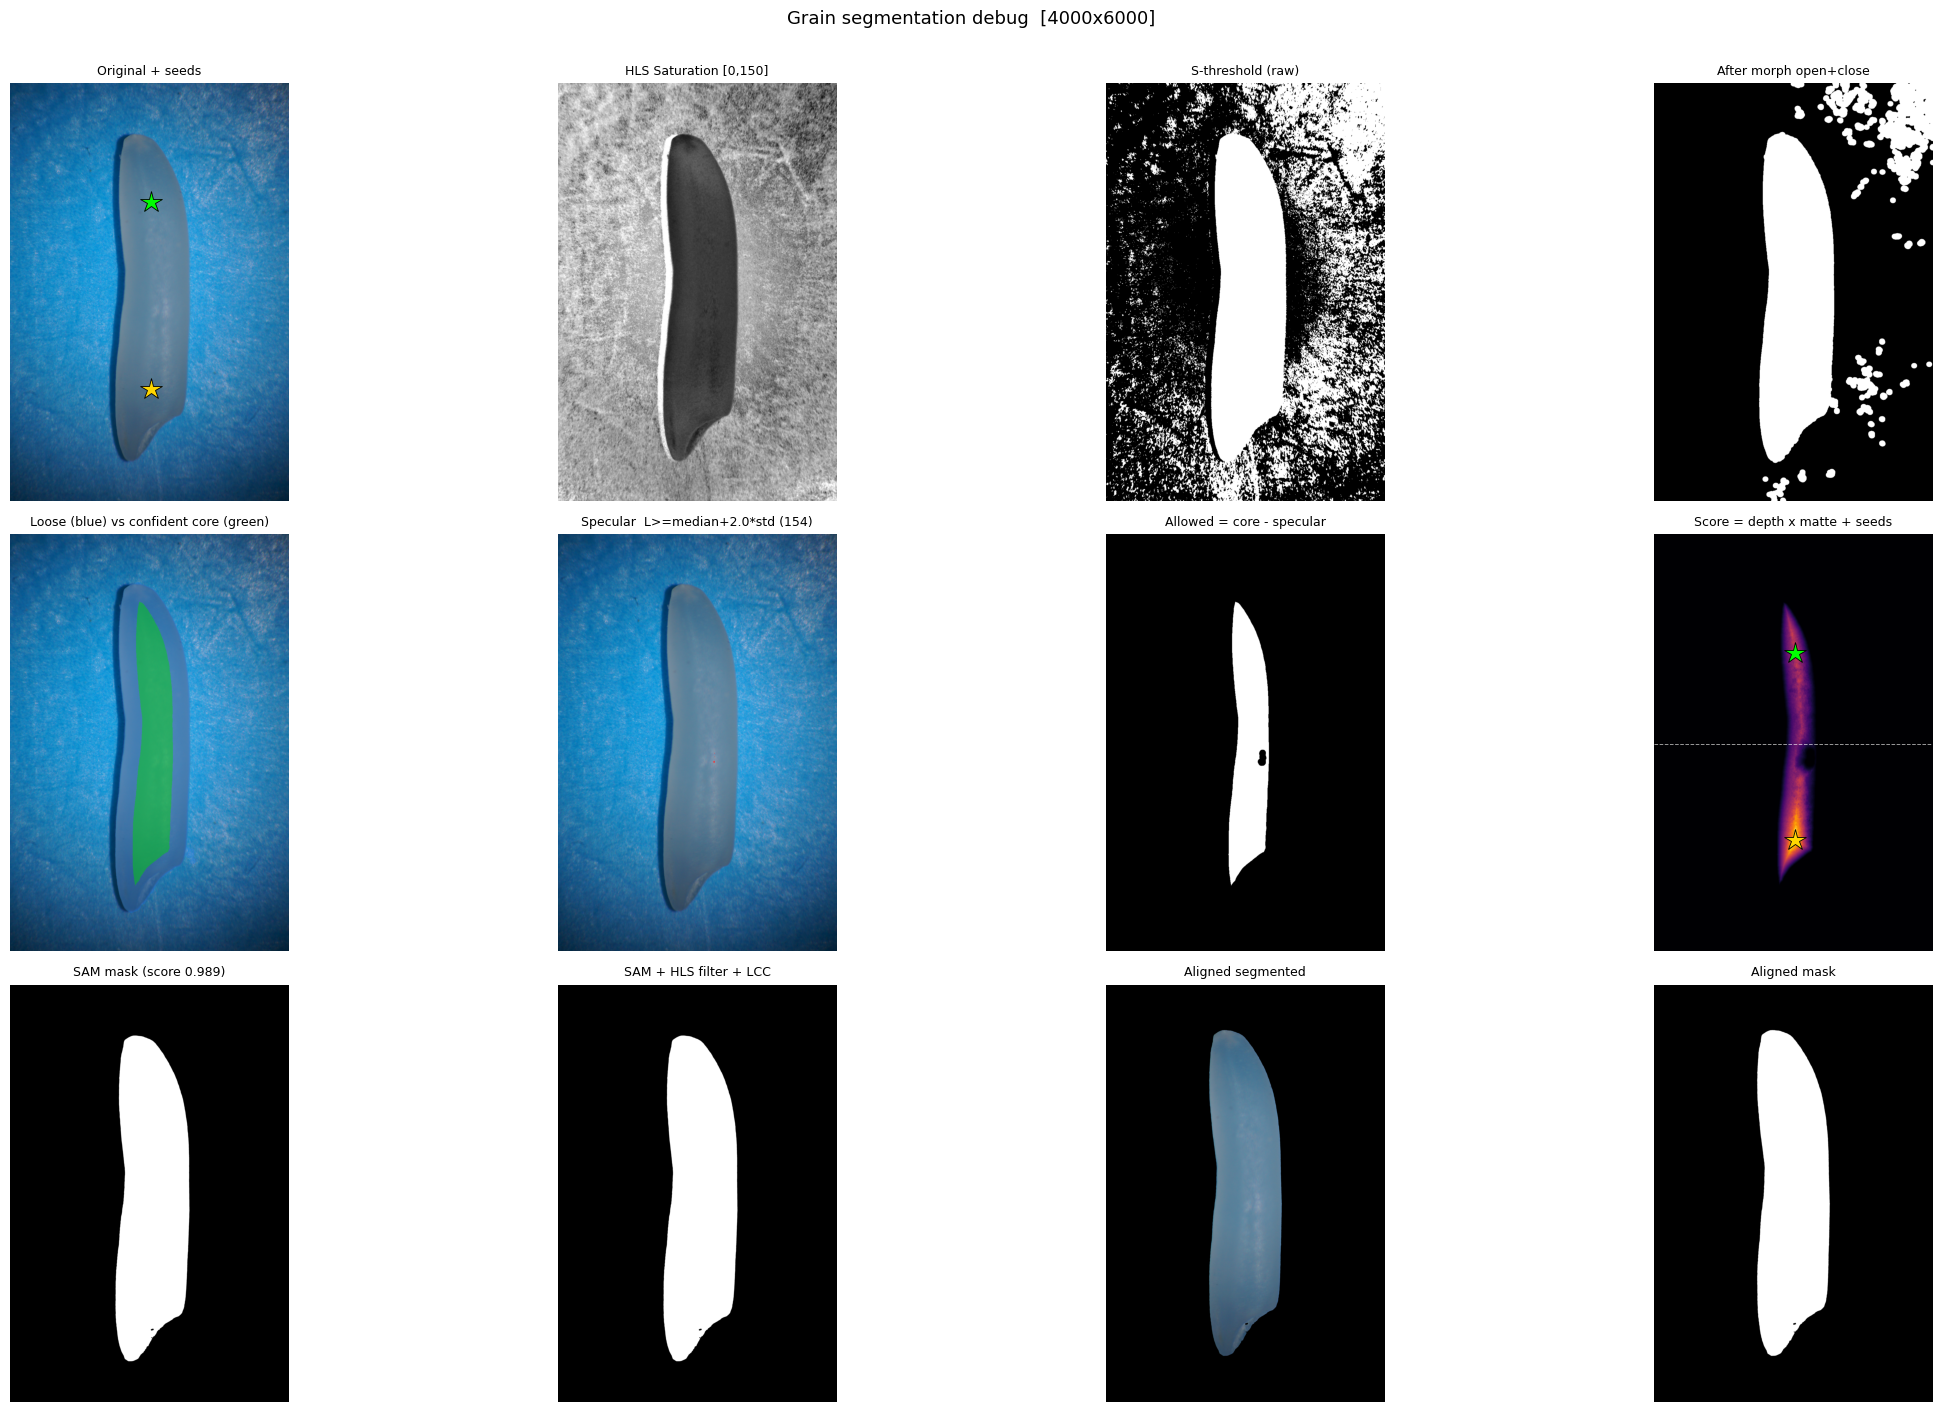

In [22]:
IMG_DIR = Path(cfg.ORIGINAL_IMAGE_DIR / "Basmati and non-basmati/PB1121/PB1121_0001.JPG") # Change this diectory to test different images
img = cv2.imread(str(IMG_DIR))
debug_segmentation(img)

## Batch segmentation (except the peck damage)

#### with log file

In [ ]:
from tqdm import tqdm
from datetime import datetime
import cv2

VALID = (".jpg", ".jpeg", ".png", ".tif", ".tiff")
Directory = cfg.ORIGINAL_IMAGE_DIR
Output_Directory = cfg.SEGMENTED_IMAGE_DIR
LOG_PATH = Output_Directory / "segmentation_failures.log"

Output_Directory.mkdir(parents=True, exist_ok=True)

EXCLUDE = {"Peck_damage"}   # folder names to skip (lowercased)

image_paths = [p for p in Directory.rglob("*")
               if p.is_file()
               and p.suffix.lower() in VALID
               and not (EXCLUDE & {part.lower() for part in p.parts})]
# image_paths = [p for p in Directory.rglob("*")
#                if p.is_file() and p.suffix.lower() in VALID]

failures = []
processed = 0

# open in line-buffered mode and flush after every write so the file is
# always up to date on disk, even if the cell is interrupted
log = open(LOG_PATH, "w", buffering=1)
log.write(f"Segmentation run: {datetime.now():%Y-%m-%d %H:%M:%S}\n")
log.write(f"Total images: {len(image_paths)}\n")
log.write("-" * 60 + "\n")
log.flush()

def record(rel, why):
    failures.append((rel, why))
    log.write(f"[{why}]\t{rel}\n")
    log.flush()

try:
    for img_path in tqdm(image_paths, desc="Segmenting", unit="image"):
        rel = img_path.relative_to(Directory)
        processed += 1

        # out_path = Output_Directory / rel
        # if out_path.exists():
        #     continue          # already segmented in a previous run

        image = cv2.imread(str(img_path))
        if image is None:
            record(rel, "unreadable");  continue

        mask = sam_mask(image)
        if mask.sum() == 0:
            record(rel, "empty mask");  continue

        ok, reason = check_segmentation(mask)
        if not ok:
            record(rel, reason);  continue

        aligned_img, aligned_mask = align_vertical(image, mask)
        if aligned_mask.sum() == 0:
            record(rel, "align failed");  continue

        segmented = cv2.bitwise_and(aligned_img, aligned_img, mask=aligned_mask)
        out_path = Output_Directory / rel
        out_path.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(out_path), segmented)

except KeyboardInterrupt:
    print("\nInterrupted — log saved up to this point.")

finally:
    log.write("-" * 60 + "\n")
    log.write(f"Ended: {datetime.now():%Y-%m-%d %H:%M:%S}\n")
    log.write(f"Processed: {processed}/{len(image_paths)}  |  "
              f"Succeeded: {processed - len(failures)}  |  Failed: {len(failures)}\n")
    log.flush()
    log.close()

print(f"Processed {processed}/{len(image_paths)}, {len(failures)} failed -> {LOG_PATH}")

Segmenting: 100%|██████████| 24225/24225 [14:10:20<00:00,  2.11s/image]  

Processed 24225/24225, 95 failed -> data\Segmented image\segmentation_failures.log


# Functions For peck damage

In [49]:
def get_seedpoints_peck(image_bgr, scale=4, n_seeds=3, reach=0.85):
    """
    Peck-damage seeds: purely geometric. The lesion's colour is inconsistent
    (dark brown OR bright chalky), so ignore appearance entirely and place
    n_seeds down the long axis of the LOOSE grain mask (top / mid / bottom),
    each taken at the horizontal centre of the grain at that row so it stays
    inside the silhouette.
    """
    h, w = image_bgr.shape[:2]
    small = cv2.resize(image_bgr, (w // scale, h // scale), interpolation=cv2.INTER_AREA)
    hls = cv2.cvtColor(small, cv2.COLOR_BGR2HLS)
    L, S = hls[:, :, 1], hls[:, :, 2]

    raw = cv2.inRange(hls, np.array([0, 0, cfg.HLS_S_MIN], np.uint8),
                           np.array([255, 255, cfg.HLS_S_MAX], np.uint8))
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    closed = cv2.morphologyEx(cv2.morphologyEx(raw, cv2.MORPH_OPEN, k, 2),
                              cv2.MORPH_CLOSE, k, 2)
    ko = max(7, int(min(h, w) / scale * 0.02)) | 1
    closed = cv2.morphologyEx(closed, cv2.MORPH_OPEN,
                              cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ko, ko)))
    loose = pick_grain_component(closed, S, min_area=2000)
    loose = fill_holes(loose)                              # damage often opens holes; close them

    d = dict(small=small, L=L, S=S, raw=raw, closed=closed, loose=loose,
             scale=scale, n_seeds=n_seeds,
             core=loose, highlight=np.zeros_like(loose),
             allowed=loose, score=loose.astype(np.float32), rel_thr=0)
    if loose.sum() == 0:
        d["seeds"] = [(w // 2, h // 2)]
        return d

    lb = loose > 0
    ys = np.where(lb.max(axis=1))[0]
    y0, y1 = ys.min(), ys.max()

    seeds = []
    for i in range(n_seeds):
        t = (i + 0.5) / n_seeds
        ty = int(round(y0 + (y1 - y0) * (reach * t + (1 - reach) * 0.5)))   # target row
        # nearest row that actually has grain, then take the centre of that row's span
        row = ty
        for dy in range(0, (y1 - y0) // 2 + 1):
            if lb[min(max(ty + dy, 0), lb.shape[0]-1)].any():
                row = min(max(ty + dy, 0), lb.shape[0]-1);  break
            if lb[min(max(ty - dy, 0), lb.shape[0]-1)].any():
                row = min(max(ty - dy, 0), lb.shape[0]-1);  break
        xs = np.where(lb[row])[0]
        cx = int((xs.min() + xs.max()) / 2)               # horizontal centre of the grain here
        seeds.append((int(cx * scale), int(row * scale)))

    d["seeds"] = seeds
    return d

def sam_mask_peck(image_bgr):
    predictor.set_image(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    S = get_seedpoints_peck(image_bgr, n_seeds=3)          # bright-seeking, spread
    pts = np.array(S["seeds"]);  labels = np.ones(len(pts), int)
    masks, scores, _ = predictor.predict(point_coords=pts, point_labels=labels,
                                         multimask_output=True)
    mask = masks[np.argmax(scores)].astype(np.uint8) * 255
    hls = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HLS)
    mask = cv2.bitwise_and(mask, cv2.inRange(hls, np.array([0, 0, cfg.HLS_S_MIN], np.uint8),
                                                  np.array([255, 255, cfg.HLS_S_MAX], np.uint8)))
    mask = largest_connected_component(mask)
    mask = fill_holes(mask)
    return largest_connected_component(mask)


def debug_segmentation_peck(image_bgr, figsize=(24, 14), n_seeds=3, reach=0.85, **kw):
    """12-panel diagnostic for the PECK pipeline (mirrors sam_mask_peck exactly):
    geometric seeds at top/mid/bottom of the loose mask — no appearance rule."""
    S = get_seedpoints_peck(image_bgr, n_seeds=n_seeds, reach=reach, **kw)
    h, w = image_bgr.shape[:2];  sc = S["scale"];  nb = S["n_seeds"]
    rgb  = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    srgb = cv2.cvtColor(S["small"], cv2.COLOR_BGR2RGB)

    predictor.set_image(rgb)
    pts = np.array(S["seeds"]);  labels = np.ones(len(pts), int)
    masks, scores, _ = predictor.predict(point_coords=pts, point_labels=labels,
                                         multimask_output=True)
    sam_raw = masks[np.argmax(scores)].astype(np.uint8) * 255

    hlsF = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HLS)
    sam_clean = largest_connected_component(cv2.bitwise_and(
        sam_raw, cv2.inRange(hlsF, np.array([0, 0, cfg.HLS_S_MIN], np.uint8),
                                   np.array([255, 255, cfg.HLS_S_MAX], np.uint8))))
    sam_clean = fill_holes(sam_clean)
    sam_clean = largest_connected_component(sam_clean)
    aligned_img, aligned_mask = align_vertical(image_bgr, sam_clean)
    segmented = cv2.bitwise_and(aligned_img, aligned_img, mask=aligned_mask)

    ok, reason = check_segmentation(sam_clean)

    fig, axes = plt.subplots(3, 4, figsize=figsize);  ax = axes.ravel()
    scol = ["#00FF00", "#FFD700", "#00FFFF", "#FF00FF"]
    def g(a, im, t): a.imshow(im, cmap="gray"); a.set_title(t, fontsize=9); a.axis("off")
    def c(a, im, t): a.imshow(im);              a.set_title(t, fontsize=9); a.axis("off")

    # Row 1 — input stages
    c(ax[0], rgb, "Original + seeds (top/mid/bottom)")
    for i, (x, y) in enumerate(S["seeds"]):
        ax[0].plot(x, y, "*", color=scol[i % 4], ms=16, mec="k", mew=0.6)
    g(ax[1], S["S"], f"HLS Saturation [{cfg.HLS_S_MIN},{cfg.HLS_S_MAX}]")
    g(ax[2], S["raw"], "S-threshold (raw)")
    g(ax[3], S["closed"], "After morph open+close")

    # Row 2 — loose mask + geometric seeds (no core/specular for peck)
    ov = srgb.copy()
    ov[S["loose"] > 0] = (0.6*ov[S["loose"] > 0] + 0.4*np.array([0, 220, 0])).astype(np.uint8)
    c(ax[4], ov, "Loose grain mask (green)")
    g(ax[5], S["loose"], "Loose mask (filled)")
    # long-axis span + target rows + seeds on the loose mask
    lb = S["loose"] > 0
    disp = np.zeros((*lb.shape, 3), np.uint8); disp[lb] = (60, 60, 60)
    ax[6].imshow(disp)
    if lb.any():
        ys = np.where(lb.max(axis=1))[0]; y0, y1 = ys.min(), ys.max()
        for i in range(nb):
            t = (i + 0.5) / nb
            ty = y0 + (y1 - y0) * (reach * t + (1 - reach) * 0.5)
            ax[6].axhline(ty, color="cyan", lw=0.8, ls=":", alpha=0.8)
    for i, (x, y) in enumerate(S["seeds"]):
        ax[6].plot(x//sc, y//sc, "*", color=scol[i % 4], ms=16, mec="k", mew=0.6)
    ax[6].set_title(f"Seeds on loose mask (reach={reach})", fontsize=9);  ax[6].axis("off")
    ax[7].axis("off")
    ax[7].text(0.5, 0.5, "PECK: geometric seeding\n(no appearance rule)",
               ha="center", va="center", fontsize=11, transform=ax[7].transAxes,
               bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

    # Row 3 — SAM output
    g(ax[8], sam_raw, f"SAM mask (score {scores.max():.3f})")
    g(ax[9], sam_clean, f"SAM + HLS + LCC + fill  [{reason}]")
    c(ax[10], cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB), "Aligned segmented (EXPORTED)")
    g(ax[11], aligned_mask, "Aligned mask")

    verdict = "PASS" if ok else f"FAIL: {reason}"
    fig.suptitle(f"PECK debug  [{w}x{h}]   seeds={len(S['seeds'])}   {verdict}",
                 fontsize=13, y=1.005)
    fig.tight_layout();  plt.show()

    


## Test for Peck

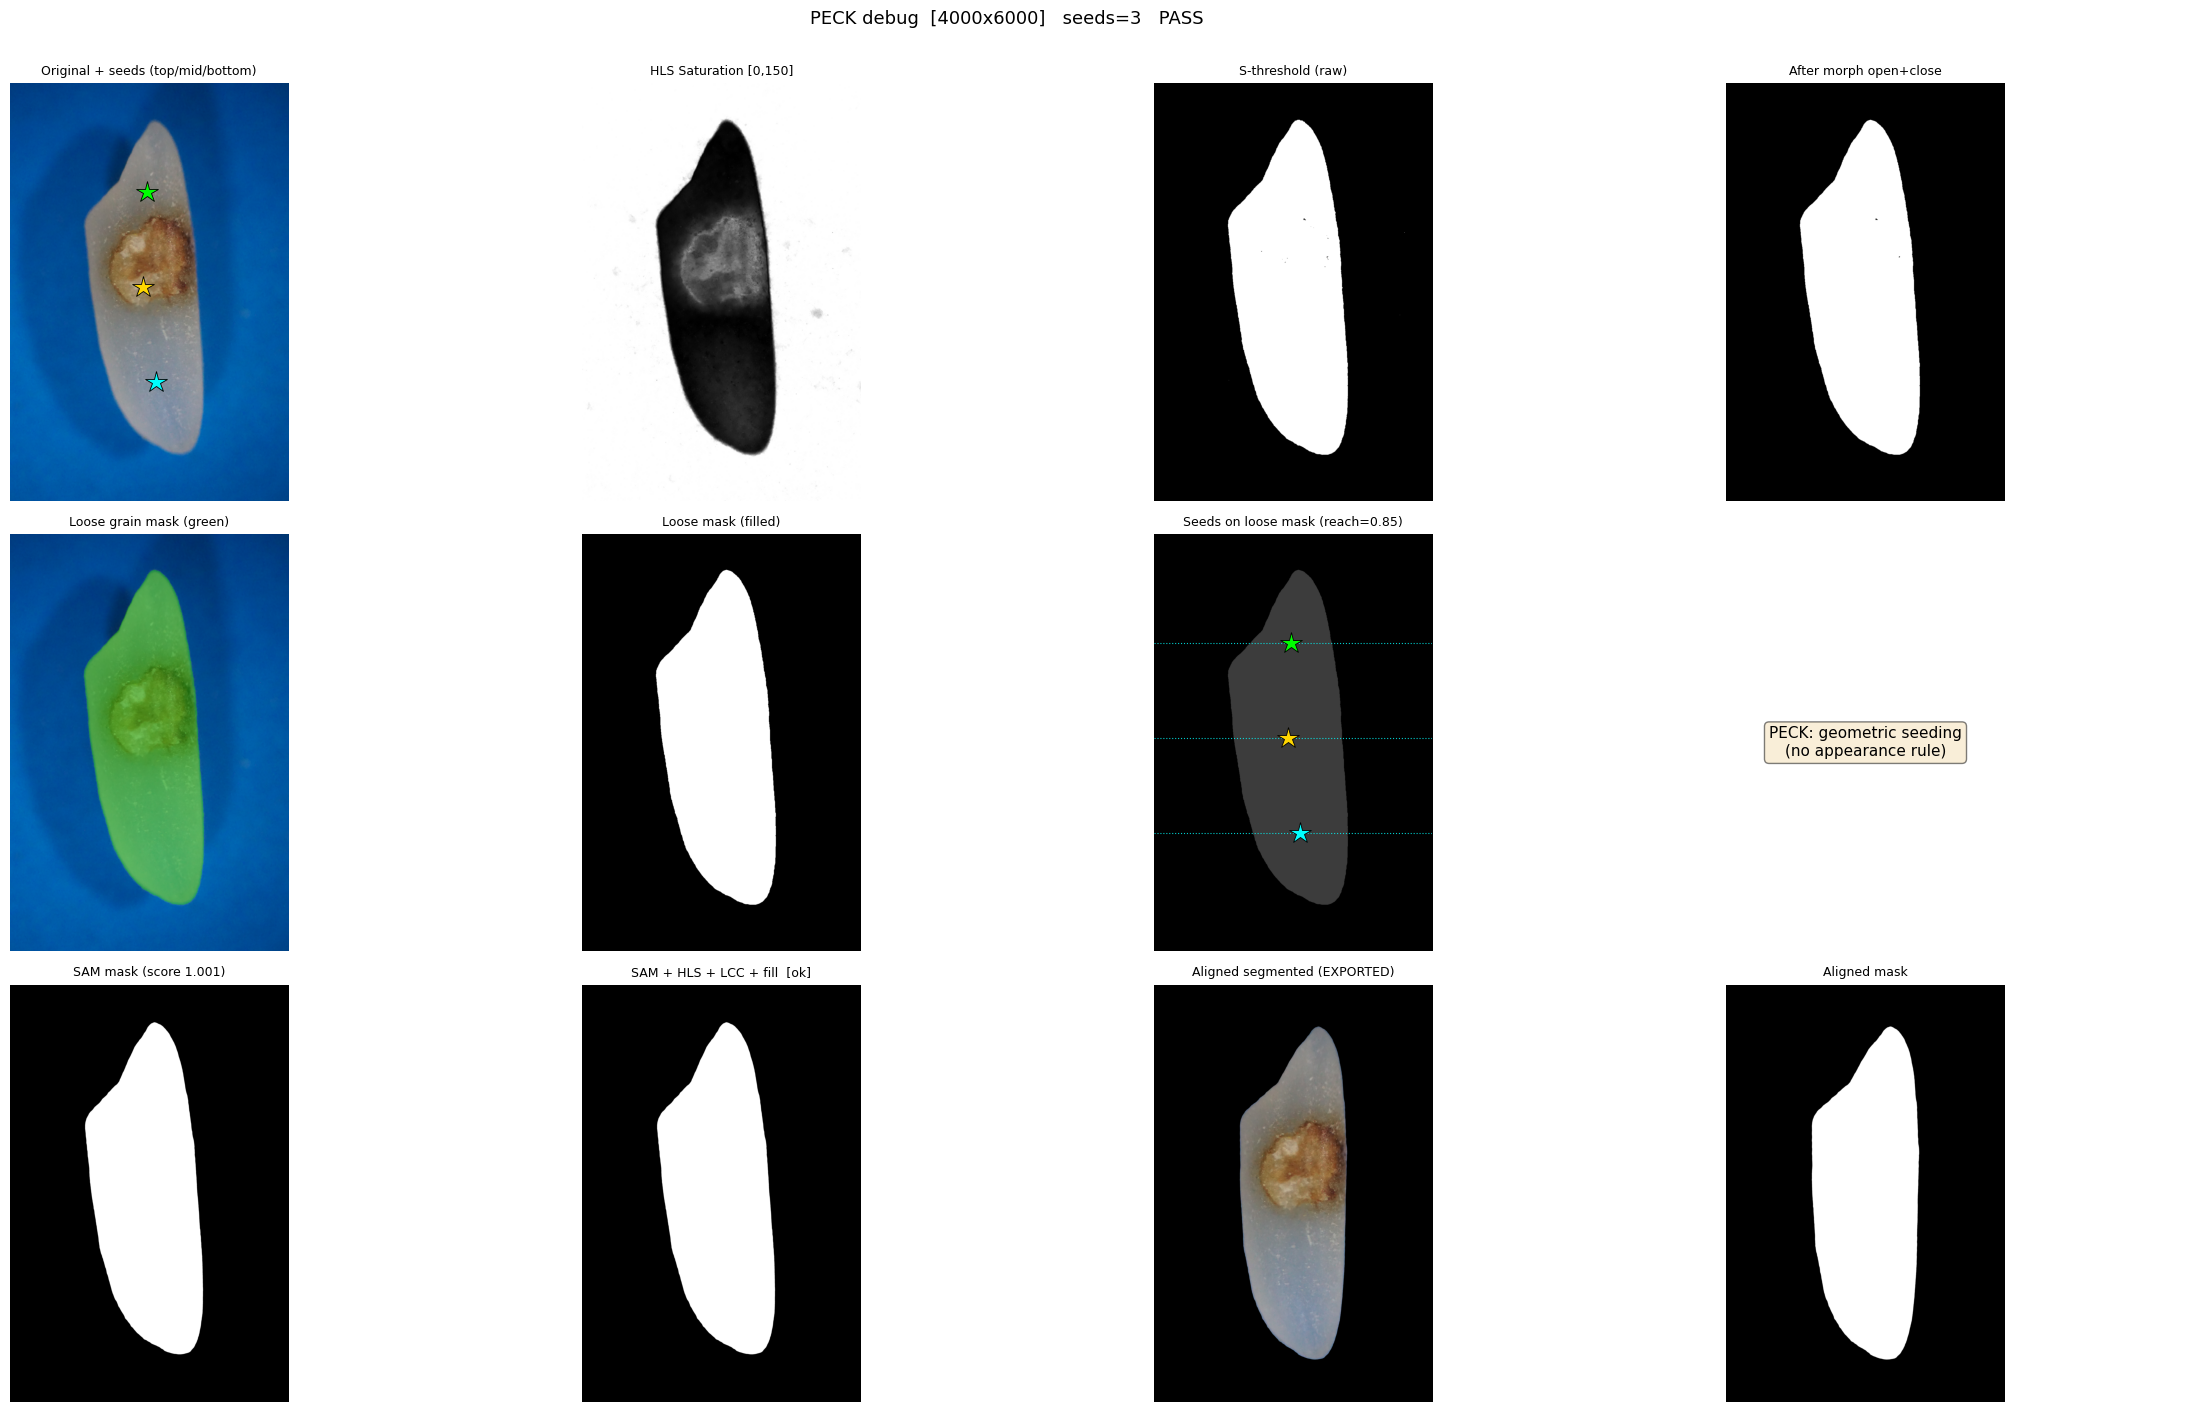

In [48]:
IMG_DIR = Path(cfg.ORIGINAL_IMAGE_DIR / "BPT5204/Peck_damage/BPT5204_PD_0033.JPG") # Change this diectory to test different images
img = cv2.imread(str(IMG_DIR))
debug_segmentation_peck(img)

## Batch for peck damage

In [50]:
from tqdm import tqdm
from datetime import datetime
import cv2, numpy as np

VALID = (".jpg", ".jpeg", ".png", ".tif", ".tiff")
Directory = cfg.ORIGINAL_IMAGE_DIR
Output_Directory = cfg.SEGMENTED_IMAGE_DIR
LOG_PATH = Output_Directory / "segmentation_failures_peck.log"

Output_Directory.mkdir(parents=True, exist_ok=True)

image_paths = [p for p in Directory.rglob("*")
               if p.is_file()
               and p.suffix.lower() in VALID
               and "peck_damage" in {part.lower() for part in p.parts}]

failures = []
processed = 0

log = open(LOG_PATH, "w", buffering=1)
log.write(f"Peck-damage segmentation run: {datetime.now():%Y-%m-%d %H:%M:%S}\n")
log.write(f"Total images: {len(image_paths)}\n")
log.write("-" * 60 + "\n")
log.flush()

def record(rel, why):
    failures.append((rel, why))
    log.write(f"[{why}]\t{rel}\n")
    log.flush()

try:
    for img_path in tqdm(image_paths, desc="Segmenting (peck)", unit="image"):
        rel = img_path.relative_to(Directory)
        processed += 1

        image = cv2.imread(str(img_path))
        if image is None:
            record(rel, "unreadable");  continue

        mask = sam_mask_peck(image)
        if mask.sum() == 0:
            record(rel, "empty mask");  continue

        ok, reason = check_segmentation(mask)
        if not ok:
            record(rel, reason);  continue

        aligned_img, aligned_mask = align_vertical(image, mask)
        if aligned_mask.sum() == 0:
            record(rel, "align failed");  continue

        segmented = cv2.bitwise_and(aligned_img, aligned_img, mask=aligned_mask)
        out_path = Output_Directory / rel
        out_path.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(out_path), segmented)

except KeyboardInterrupt:
    print("\nInterrupted — log saved up to this point.")

finally:
    log.write("-" * 60 + "\n")
    log.write(f"Ended: {datetime.now():%Y-%m-%d %H:%M:%S}\n")
    log.write(f"Processed: {processed}/{len(image_paths)}  |  "
              f"Succeeded: {processed - len(failures)}  |  Failed: {len(failures)}\n")
    log.flush()
    log.close()

print(f"Processed {processed}/{len(image_paths)}, {len(failures)} failed -> {LOG_PATH}")

Segmenting (peck): 100%|██████████| 2128/2128 [1:04:14<00:00,  1.81s/image]

Processed 2128/2128, 0 failed -> data\Segmented image\segmentation_failures_peck.log


## Manually handling the failed images

The error files are located in the SEGMENTED_IMAGE_DIR. Keep the Observed_failures.txt containing the list of failed dsegmentation in the same folder

In [67]:
import re
from pathlib import Path

def _parse_log(path):
    out = []
    if not Path(path).exists():
        return out
    for line in open(path, encoding="utf-8", errors="ignore"):
        m = re.match(r"\[(.+?)\]\s+(.+)", line.strip())
        if m:
            out.append(m.group(2).strip())
    return out

def _parse_plain(path):
    if not Path(path).exists():
        print(f"WARNING: {path} not found (cwd={Path.cwd()})")
        return []
    return [l.strip() for l in open(path, encoding="utf-8", errors="ignore") if l.strip()]

# --- point these at the real locations ---
OBSERVED_TXT = cfg.SEGMENTED_IMAGE_DIR / "Observed_failures.txt"

sources = (
    _parse_log(cfg.SEGMENTED_IMAGE_DIR / "segmentation_failures.log")
    + _parse_log(cfg.SEGMENTED_IMAGE_DIR / "segmentation_failures_peck.log")
    + _parse_plain(OBSERVED_TXT)
)


# print(f"{len(sources)} total failure lines (before dedupe)")

# dedupe + resolve BOTH original and segmented paths
seen, work_list, missing_orig, missing_seg = set(), [], [], []
for rel in sources:
    rel_norm = rel.replace("\\", "/").strip()
    key = rel_norm.lower()
    if key in seen:
        continue
    seen.add(key)

    def _resolve(base):
        p = base / rel_norm
        if p.exists():
            return p
        parent = p.parent
        if parent.exists():                            # case-insensitive fallback
            hit = next((f for f in parent.iterdir()
                        if f.name.lower() == p.name.lower()), None)
            if hit:
                return hit
        return None

    src = _resolve(cfg.ORIGINAL_IMAGE_DIR)
    seg = _resolve(cfg.SEGMENTED_IMAGE_DIR)

    if src is None:
        missing_orig.append(rel_norm)
        continue
    rel_final = src.relative_to(cfg.ORIGINAL_IMAGE_DIR)
    work_list.append(rel_final)
    if seg is None:                                    # segmented output missing (was skipped, not saved)
        missing_seg.append(str(rel_final))

print(f"\n{len(work_list)} images to fix (originals found)")
print(f"  {len(work_list) - len(missing_seg)} already have a segmented output to replace")
print(f"  {len(missing_seg)} have NO segmented output yet (will be created fresh)")

if missing_orig:
    # print(f"\n{len(missing_orig)} ORIGINALS NOT FOUND under {cfg.ORIGINAL_IMAGE_DIR}:")
    for m in missing_orig:
        print(f"  {m}")

# if missing_seg:
#     # print(f"\n{len(missing_seg)} have no existing segmented file (fine — they'll be written on submit):")
#     for m in missing_seg:
#         print(f"  {m}")


28 images to fix (originals found)
  28 already have a segmented output to replace
  0 have NO segmented output yet (will be created fresh)


In [66]:
import cv2, numpy as np, matplotlib.pyplot as plt
from datetime import datetime
import ipywidgets as widgets
from IPython.display import display

%matplotlib widget

MANUAL_LOG = cfg.SEGMENTED_IMAGE_DIR / "manual_segmentation.log"

class ManualSegmenter:
    def __init__(self, rel_paths):
        self.rels = list(rel_paths)
        self.idx = 0
        self.done = set()
        self._log = open(MANUAL_LOG, "a", buffering=1)
        self._log.write(f"\n# Manual session {datetime.now():%Y-%m-%d %H:%M:%S}  "
                        f"({len(self.rels)} images)\n")
        self._build()
        self.load()

    # ---------- SAM ----------
    def run_sam(self):
        if not self.pts:
            self.mask = np.zeros(self.image.shape[:2], np.uint8)
            return
        predictor.set_image(cv2.cvtColor(self.image, cv2.COLOR_BGR2RGB))
        pts = np.array([[x, y] for (x, y, _) in self.pts])
        lbl = np.array([l for (_, _, l) in self.pts])
        masks, scores, _ = predictor.predict(point_coords=pts, point_labels=lbl,
                                             multimask_output=True)
        m = masks[np.argmax(scores)].astype(np.uint8) * 255
        hls = cv2.cvtColor(self.image, cv2.COLOR_BGR2HLS)
        m = cv2.bitwise_and(m, cv2.inRange(hls, np.array([0,0,cfg.HLS_S_MIN],np.uint8),
                                              np.array([255,255,cfg.HLS_S_MAX],np.uint8)))
        m = largest_connected_component(m)
        m = fill_holes(m)
        self.mask = largest_connected_component(m)

    # ---------- data ----------
    def load(self):
        rel = self.rels[self.idx]
        self.image = cv2.imread(str(cfg.ORIGINAL_IMAGE_DIR / rel))
        self.pts = []                       # list of (x, y, label)  label 1=pos 0=neg
        self.mask = np.zeros(self.image.shape[:2], np.uint8)
        self.title.value = (f"<b>[{self.idx+1}/{len(self.rels)}]</b> {rel}  "
                            f"&nbsp; done: {len(self.done)}/{len(self.rels)}")
        self.refresh()

    # ---------- rendering ----------
    def refresh(self):
        self.run_sam()
        rgb = cv2.cvtColor(self.image, cv2.COLOR_BGR2RGB)
        seg = cv2.bitwise_and(self.image, self.image, mask=self.mask)
        seg = cv2.cvtColor(seg, cv2.COLOR_BGR2RGB)

        for a in self.ax: a.clear(); a.axis("off")
        # left: image + points + mask outline
        self.ax[0].imshow(rgb)
        if self.mask.any():
            self.ax[0].contour(self.mask, levels=[127], colors="yellow", linewidths=1.5)
        for (x, y, l) in self.pts:
            self.ax[0].plot(x, y, "o", ms=9, mfc=("lime" if l else "red"),
                            mec="black", mew=1.2)
        self.ax[0].set_title("Click to add point  (mode below)", fontsize=9)
        # right: segmented result
        self.ax[1].imshow(seg)
        self.ax[1].set_title(f"Segmented  ({int(self.mask.sum()/255)} px)", fontsize=9)
        self.fig.canvas.draw_idle()
        # point list
        if self.pts:
            self.plist.value = "<br>".join(
                f"{i}: ({x},{y}) <b>{'＋pos' if l else '－neg'}</b>"
                for i, (x, y, l) in enumerate(self.pts))
        else:
            self.plist.value = "<i>no points yet</i>"

    # ---------- events ----------
    def on_click(self, event):
        if event.inaxes != self.ax[0] or event.xdata is None:
            return
        lbl = 1 if self.mode.value == "positive" else 0
        self.pts.append((int(event.xdata), int(event.ydata), lbl))
        self.refresh()

    def remove_last(self, _=None):
        if self.pts:
            self.pts.pop(); self.refresh()

    def clear_pts(self, _=None):
        self.pts = []; self.refresh()

    def submit(self, _=None):
        if not self.mask.any():
            self.msg.value = "<span style='color:red'>no mask — add points first</span>"
            return
        aligned_img, aligned_mask = align_vertical(self.image, self.mask)
        segmented = cv2.bitwise_and(aligned_img, aligned_img, mask=aligned_mask)
        rel = self.rels[self.idx]
        out = cfg.SEGMENTED_IMAGE_DIR / rel
        out.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(out), segmented)
        self.done.add(str(rel))
        pts_str = ";".join(f"({x},{y},{'p' if l else 'n'})" for x,y,l in self.pts)
        self._log.write(f"[saved]\t{rel}\tpoints={pts_str}\n")
        self.msg.value = f"<span style='color:green'>saved {rel.name}</span>"
        self.title.value = (f"<b>[{self.idx+1}/{len(self.rels)}]</b> {rel}  "
                            f"&nbsp; done: {len(self.done)}/{len(self.rels)}")

    def go(self, step):
        self.idx = (self.idx + step) % len(self.rels)
        self.msg.value = ""
        self.load()

    def close(self, _=None):
        self._confirm.layout.display = "flex"

    def _do_close(self, _=None):
        self._log.write(f"# closed {datetime.now():%Y-%m-%d %H:%M:%S}  "
                        f"done {len(self.done)}/{len(self.rels)}\n")
        self._log.close()
        plt.close(self.fig)
        self.box.close()
        print(f"Closed. {len(self.done)}/{len(self.rels)} saved -> {MANUAL_LOG}")

    def _cancel_close(self, _=None):
        self._confirm.layout.display = "none"

    def on_key(self, event):
        if   event.key == "enter":      self.submit()
        elif event.key == "right":      self.go(+1)
        elif event.key == "left":       self.go(-1)
        elif event.key == "escape":     self.close()
        elif event.key in ("backspace","delete"): self.remove_last()

    # ---------- layout ----------
    def _build(self):
        plt.ioff()
        self.fig, self.ax = plt.subplots(1, 2, figsize=(11, 6))
        self.fig.canvas.header_visible = False
        self.fig.canvas.toolbar_visible = True          # zoom/pan; resize handle at corner
        self.fig.canvas.mpl_connect("button_press_event", self.on_click)
        self.fig.canvas.mpl_connect("key_press_event", self.on_key)
        plt.ion()

        self.title = widgets.HTML()
        self.mode  = widgets.ToggleButtons(options=["positive","negative"],
                                           description="Add:", button_style="")
        self.plist = widgets.HTML(layout=widgets.Layout(border="1px solid #ccc",
                                  padding="4px", height="150px", overflow="auto"))
        self.msg   = widgets.HTML()

        b_rm   = widgets.Button(description="Remove last (⌫)")
        b_clr  = widgets.Button(description="Clear")
        b_sub  = widgets.Button(description="Submit (Enter)", button_style="success")
        b_prev = widgets.Button(description="◀ Prev (←)")
        b_next = widgets.Button(description="Next ▶ (→)")
        b_esc  = widgets.Button(description="Close (Esc)", button_style="danger")
        b_rm.on_click(self.remove_last); b_clr.on_click(self.clear_pts)
        b_sub.on_click(self.submit);     b_prev.on_click(lambda _: self.go(-1))
        b_next.on_click(lambda _: self.go(+1)); b_esc.on_click(self.close)

        # confirm-close overlay
        cyes = widgets.Button(description="Yes, close", button_style="danger")
        cno  = widgets.Button(description="Cancel")
        cyes.on_click(self._do_close); cno.on_click(self._cancel_close)
        self._confirm = widgets.HBox([widgets.HTML("<b>Close the tool?</b>"), cyes, cno])
        self._confirm.layout.display = "none"

        controls = widgets.VBox([
            self.mode,
            widgets.HBox([b_rm, b_clr]),
            widgets.HTML("<b>Points</b>"), self.plist,
            b_sub,
            widgets.HBox([b_prev, b_next]),
            b_esc, self.msg,
        ], layout=widgets.Layout(width="330px"))

        self.box = widgets.VBox([
            self.title,
            self._confirm,
            widgets.HBox([self.fig.canvas, controls]),
        ])
        display(self.box)

# launch
seg_tool = ManualSegmenter(work_list)